# Skilling Experiment 4
## Breast Cancer Wisconsin --- Logistic Regression and Regularisation

**25SC2107E -- Machine Learning** | Course Outcome: CO2

---

### Aim
Build a logistic regression classifier that tells malignant tumours from benign ones,
deliberately create a situation with **more features than patients**, and show that
regularisation rescues it.

In House pricing regularisation made almost no difference. Here it makes a large one,
and **the reason for the difference is the real lesson**.

### Before you start
Run each cell with `Shift+Enter`. Do not skip cells --- later cells use variables
made in earlier ones. Everything uses `random_state=42`, so your numbers should
match the ones in the manual exactly.

## Cell 1 --- Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

Only **one** model is imported this time. In Experiment House Pricing Prediction the penalty came from a
different class each time (`Ridge`, `Lasso`, `ElasticNet`). In logistic regression all
three are settings *inside* `LogisticRegression`, chosen with the `penalty` argument.

`PolynomialFeatures` is the new tool. It is what will turn 30 features into 495.

## Cell 2 --- Load the data

In [2]:
data = load_breast_cancer(as_frame=True)
cancer = data.frame

print(cancer.shape)
print(cancer["target"].value_counts())
print(data.target_names)
cancer.head()

(569, 31)
target
1    357
0    212
Name: count, dtype: int64
['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


569 rows and 31 columns: the 30 measurements plus the answer.

`target_names` prints `['malignant' 'benign']`. The order matters: it tells you
**0 is malignant and 1 is benign**. This feels backwards, because 1 usually means
"the thing we are looking for". **Check this on every medical dataset before you read
a single result.**

## Cell 3 --- The baseline you must beat

In [3]:
print("Always-benign accuracy:", round(cancer["target"].mean(), 4))

Always-benign accuracy: 0.6274


357 of 569 tumours are benign, so a lazy model that says "benign" every single time is
right **62.7%** of the time. Any model that cannot beat 0.627 has learned nothing.

That lazy model would also miss *every single cancer*, which is the worst possible
mistake here. Accuracy alone will never show you that, which is why Cell 10 uses a
confusion matrix.

## Cell 4 --- A deliberately small training set

In [4]:
X = cancer.drop(columns="target")
y = cancer["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=100, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(100, 30) (469, 30)


`train_size=100` keeps only 100 patients for training and leaves 469 for testing. That
is backwards from normal practice, and it is **on purpose**: we want a small training
set so that overfitting actually happens where you can see it.

This is not as artificial as it sounds. Labelled medical data is genuinely scarce,
because every label needs a biopsy and a pathologist.

`stratify=y` keeps the same malignant-to-benign ratio in both halves. This matters far
more with 100 rows than with 16,512.

## Cell 5 --- Make 495 features out of 30

In [5]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_p = poly.fit_transform(X_train)
X_test_p = poly.transform(X_test)
print("after expansion:", X_train_p.shape, X_test_p.shape)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_p)
X_test_s = scaler.transform(X_test_p)

after expansion: (100, 495) (469, 495)


`PolynomialFeatures(degree=2)` keeps the original 30 features and adds every square
(`radius**2`) and every pair multiplied together (`radius x texture`).
That gives 30 + 30 + 435 = **495** features.

Why do this at all? Plain logistic regression can only draw a straight boundary.
Products of features let it draw curved ones, which can genuinely help. The catch is
the count.

**Look hard at the shape: 100 rows, 495 columns.** There are now nearly five times as
many features as patients. A model in this situation can always find some combination
that separates the training data perfectly, even if that combination is pure coincidence.

## Cell 6 --- What happens with no penalty at all

In [6]:
big = LogisticRegression(C=10000, max_iter=20000)
big.fit(X_train_s, y_train)

train_acc = accuracy_score(y_train, big.predict(X_train_s))
test_acc = accuracy_score(y_test, big.predict(X_test_s))

print("train:", round(train_acc, 4))
print("test :", round(test_acc, 4))
print("gap  :", round(train_acc - test_acc, 4))

train: 1.0
test : 0.9232
gap  : 0.0768


**Training accuracy is 1.0000. Perfect. Every one of the 100 patients classified
correctly.** If you ever see a perfect training score, do not celebrate --- get suspicious.

Test accuracy is **0.9232**, which is 7.7 points lower. That difference is the
**generalisation gap**, and it is the fingerprint of overfitting.

The model has not learned what a tumour is. It has **memorised 100 patients**. With 495
knobs and 100 examples there is more than enough freedom to do that.

---
## `C` is not `alpha`. It is upside down.

In House Pricing, `Ridge(alpha=...)` took `alpha`, and **bigger `alpha` meant a stronger
penalty**.

`LogisticRegression` takes `C` instead, and

$$ C = \frac{1}{\alpha} $$

so **bigger `C` means a _weaker_ penalty**. Everything is reversed.

| You want | Ridge / Lasso | LogisticRegression |
|---|---|---|
| No penalty (overfits) | `alpha = 0` | `C = 10000` (very large) |
| A gentle penalty | small `alpha` | large `C` |
| A strong penalty | large `alpha` | **small** `C` |
| Everything wiped out | `alpha` huge | `C` tiny |

This single inversion causes more confusion than anything else in this topic. If your
accuracy-versus-`C` plot looks like the mirror image of what you expected, this is why.

---

## Cell 7 --- L2: accuracy against C

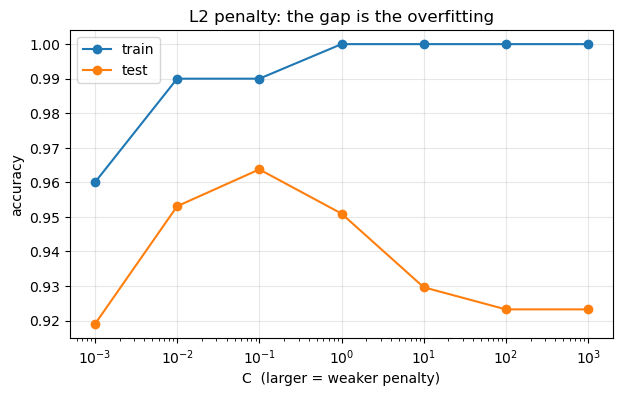

,C,train,test,gap
0,0.001,0.96,0.9190,0.0410
1,0.010,0.99,0.9531,0.0369
2,0.100,0.99,0.9638,0.0262
3,1.000,1.00,0.9510,0.0490
4,10.000,1.00,0.9296,0.0704
5,100.000,1.00,0.9232,0.0768
6,1000.000,1.00,0.9232,0.0768


In [7]:
Cs = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
l2_train, l2_test = [], []

for C in Cs:
    model = LogisticRegression(penalty="l2", C=C, max_iter=20000)
    model.fit(X_train_s, y_train)
    l2_train.append(accuracy_score(y_train, model.predict(X_train_s)))
    l2_test.append(accuracy_score(y_test, model.predict(X_test_s)))

plt.figure(figsize=(7, 4))
plt.plot(Cs, l2_train, marker="o", label="train")
plt.plot(Cs, l2_test, marker="o", label="test")
plt.xscale("log")
plt.xlabel("C  (larger = weaker penalty)")
plt.ylabel("accuracy")
plt.title("L2 penalty: the gap is the overfitting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({"C": Cs,
              "train": np.round(l2_train, 4),
              "test": np.round(l2_test, 4),
              "gap": np.round(np.array(l2_train) - np.array(l2_test), 4)})

**Plot train and test on the same axes.** A test curve alone tells you which model is
best; both curves together tell you *why*, and that is what you are here to learn.

Read the picture right to left, from weak penalty to strong. On the right the two curves
are far apart: train 1.000, test 0.923. Move left and the training curve comes down while
the test curve goes **up**. They meet at `C = 0.1`, where test accuracy peaks at **0.9638**.

**That is regularisation working: about 4 points of accuracy gained by making the model
deliberately worse at the data it was trained on.**

Push further left to `C = 0.001` and both curves fall together. The penalty is now so
heavy the model cannot learn even the real patterns. **Too much is as bad as too little.**

## Cell 8 --- L1: accuracy against C, and how many features survive

In [8]:
l1_test, kept = [], []

for C in Cs:
    model = LogisticRegression(penalty="l1", C=C, solver="liblinear",
                               random_state=42, max_iter=20000)
    model.fit(X_train_s, y_train)
    l1_test.append(accuracy_score(y_test, model.predict(X_test_s)))
    kept.append(int((model.coef_ != 0).sum()))

pd.DataFrame({"C": Cs,
              "test_acc": np.round(l1_test, 4),
              "features_used": kept})

,C,test_acc,features_used
0,0.001,0.3731,0
1,0.010,0.3731,0
2,0.100,0.9574,6
3,1.000,0.9659,13
4,10.000,0.9446,52
5,100.000,0.9296,117
6,1000.000,0.9168,234


**`penalty="l1"` needs `solver="liblinear"` or `"saga"`.** The default `lbfgs` solver
cannot do L1 and will raise an error. This is the second most common mistake in this
topic, after the `C` inversion.

`random_state=42` matters here: `liblinear` is slightly random, so without a seed you get
a different number of surviving features each run.

Read the `features_used` column downwards --- this is the whole point of L1. It goes
**0, 0, 6, 13, 52, 117, 234** out of 495. The penalty is not just shrinking coefficients,
it is **switching features off completely**.

The best row is `C = 1`: **test accuracy 0.9659 using 13 features out of 495**. Better
accuracy than the model that used all of them, from about one fortieth of the inputs.

At `C = 0.01` every feature is gone and accuracy collapses to **0.3731**. With nothing
left to work with the model predicts "malignant" for everyone --- and 0.3731 is simply
the fraction of the test set that really is malignant.

## Cell 9 --- Which features did L1 keep?

In [9]:
best_l1 = LogisticRegression(penalty="l1", C=0.1, solver="liblinear",
                             random_state=42, max_iter=20000)
best_l1.fit(X_train_s, y_train)

names = poly.get_feature_names_out(X.columns)
nz = np.flatnonzero(best_l1.coef_[0])

survivors = pd.DataFrame({"feature": names[nz], "coef": best_l1.coef_[0][nz]})
survivors = survivors.reindex(
    survivors.coef.abs().sort_values(ascending=False).index)

print("kept", len(nz), "features out of", best_l1.coef_.size)
survivors

kept 6 features out of 495


,feature,coef
4,worst radius worst smoothness,-0.598793
5,worst texture worst concave points,-0.538160
3,worst radius worst texture,-0.331177
2,mean concave points worst texture,-0.272994
1,mean texture worst concave points,-0.238909
0,mean radius worst smoothness,-0.121710


Six features survive out of 495, and **every one of them is a product of two
measurements**, not a plain measurement. So the feature expansion in Cell 5 was not
wasted --- the combinations really did carry more signal than the originals.

The strongest is `worst radius x worst smoothness`. `worst concave points` and
`worst texture` also keep appearing. These are exactly the measurements pathologists
associate with malignancy, which is a good sign the model found something real rather
than noise.

All six coefficients are **negative**. Remember 1 means *benign*, so a negative weight
pushes towards **malignant**: bigger, rougher, more irregular tumours are more likely to
be cancer. Always translate the sign back into the label meaning before you claim anything.

**This is the practical reason to reach for L1.** A doctor will not act on a 495-term
formula. A six-term one built from familiar measurements can at least be discussed.

## Cell 10 --- The mistakes that actually matter

In [10]:
best_l2 = LogisticRegression(penalty="l2", C=0.1, max_iter=20000)
best_l2.fit(X_train_s, y_train)

print("rows = truth, columns = prediction, row 0 = malignant")
print()
print("No penalty:")
print(confusion_matrix(y_test, big.predict(X_test_s)))
print()
print("L2, C=0.1:")
print(confusion_matrix(y_test, best_l2.predict(X_test_s)))

rows = truth, columns = prediction, row 0 = malignant

No penalty:
[[157  18]
 [ 18 276]]

L2, C=0.1:
[[163  12]
 [  5 289]]


Rows are the truth, columns are the prediction, and row 0 is the malignant row. So the
**top-right number is malignant tumours called benign** --- a missed cancer, the error
that actually hurts someone.

- Unregularised: **18 missed cancers**
- Regularised: **12 missed cancers**, and far fewer false alarms too (5 against 18)

**So regularisation did not just move a decimal point in an accuracy score. It found 6
more cancers out of 469 patients.** That is what the 4-point gain in Cell 7 means once
you translate it back into people.

Never report accuracy alone for a medical classifier. Two models with identical accuracy
can distribute their mistakes very differently, and here one kind of mistake is far worse
than the other.

---
## Deliverable --- `classification_benchmark()`

Write a function that fits every combination and ranks them by test accuracy.

In [11]:
def classification_benchmark(X_train, y_train, X_test, y_test, Cs):
    models = {"No penalty": LogisticRegression(penalty=None, max_iter=20000)}

    for C in Cs:
        models["L2 C=" + str(C)] = LogisticRegression(
            penalty="l2", C=C, max_iter=20000)
        models["L1 C=" + str(C)] = LogisticRegression(
            penalty="l1", C=C, solver="liblinear",
            random_state=42, max_iter=20000)
        models["ElasticNet C=" + str(C)] = LogisticRegression(
            penalty="elasticnet", C=C, l1_ratio=0.5, solver="saga",
            random_state=42, max_iter=20000)

    rows = []
    for name in models:
        model = models[name]
        model.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc = accuracy_score(y_test, model.predict(X_test))
        rows.append({
            "model": name,
            "train_acc": train_acc,
            "test_acc": test_acc,
            "gap": train_acc - test_acc,
            "features_used": int((model.coef_ != 0).sum()),
        })

    table = pd.DataFrame(rows)
    table = table.sort_values("test_acc", ascending=False).reset_index(drop=True)
    return table.round(4)


results = classification_benchmark(X_train_s, y_train, X_test_s, y_test,
                                   [0.01, 0.1, 1, 100])
results

,model,train_acc,test_acc,gap,features_used
0,L1 C=1,0.99,0.9659,0.0241,13
1,L2 C=0.1,0.99,0.9638,0.0262,495
2,ElasticNet C=1,0.99,0.9616,0.0284,134
3,L1 C=0.1,0.98,0.9574,0.0226,6
4,L2 C=0.01,0.99,0.9531,0.0369,495
5,ElasticNet C=100,1.00,0.9510,0.0490,491
6,L2 C=1,1.00,0.9510,0.0490,495
7,ElasticNet C=0.1,0.98,0.9318,0.0482,47
8,L1 C=100,1.00,0.9296,0.0704,117
9,No penalty,1.00,0.9232,0.0768,495


Same pattern as House Pricing: a dictionary of named models, one loop, one dictionary of
results per model, one DataFrame at the end. Only the contents changed, not the shape of
the code.

**Compare the top row with the `No penalty` row.** The winner is `L1 C=1` at **0.9659**
using **13** features; `No penalty` sits near the bottom at **0.9232** using all **495**.
Better accuracy, 38 times fewer features.

**Read the `gap` column as a lie detector.** Every model with `train_acc` of 1.00 has a
gap of 0.05 or worse. Every good model has a gap near 0.02 and a training score slightly
*below* perfect. A model that is not quite perfect on its own training data is usually
the more trustworthy one.

The two rows at the bottom with `features_used = 0` are the over-penalised ones. Their gap
is tiny, near 0.003 --- **proof that a small gap alone is not a good sign.** A model that
knows nothing is equally ignorant on both sets. Always read the gap next to the accuracy,
never on its own.

`penalty=None` is the modern spelling. Older tutorials use `penalty='none'` as a string,
which is removed in current scikit-learn.

---
## When does regularisation help?

| | House Pricing | Breast cancer |
|---|---|---|
| Rows | 16,512 | 100 |
| Features | 8 | 495 |
| Rows per feature | ~2,000 | ~0.2 |
| Effect of regularisation | almost none | +4 points, 97% of features removed |

**The rule of thumb: the fewer rows you have per feature, the more regularisation
matters.**

When data is plentiful and features are few, the data itself keeps the model honest and
you can skip the tuning. When features approach or outnumber rows --- after a polynomial
expansion, with text or gene data, or simply when labels are expensive --- regularisation
is not an optional refinement. It is the difference between a model that works and one
that has only memorised.

And the three penalties behave exactly as they did in House Pricing: **L2** shrinks every
coefficient but deletes none, **L1** sets coefficients to exactly zero and so selects
features, and **ElasticNet** mixes the two through `l1_ratio`. The only thing that changed
is the name of the knob: `C`, turning the opposite way.

---
## Exercises

1. Change `train_size` from 100 to 400 and re-run. Does the gap in Cell 6 shrink? Does
   the best `C` move? Explain the link to the rows-per-feature rule above.
2. Set `degree=1` in Cell 5 so there are only 30 features. Does regularisation still help?
3. In Cell 8, find the `C` that keeps roughly 20 features. How much accuracy does it cost
   compared with `C = 1`?
4. Try `l1_ratio` of 0.1 and 0.9 in the deliverable. Which behaves more like L1?
5. Missed cancers matter more than false alarms. Look up `class_weight="balanced"` and
   report what it does to the top-right number in Cell 10.